In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [71]:
iris=datasets.load_iris()
X=iris.data[50:150,1:3] #  1:100 ,1:3
y=iris.target
y=y[50:150]

In [72]:
scaler= StandardScaler()
X=scaler.fit_transform(X)

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [74]:
models=[
    ("Linear Kernal",SVC(kernel='linear',C=1)),
    ("RBF Kernal(gamma=0.5)",SVC(kernel='rbf',C=1,gamma=0.5)),
    ("RBF Kernal(gamma=5)",SVC(kernel='rbf',C=1,gamma=5)),
     ("Polynomial Kernal(degree=3)",SVC(kernel='rbf',C=1,degree=3))
]

In [75]:
h=0.02
x_min,x_max=X[:,0].min()-1,X[:,0].max()+1
y_min,y_max=X[:,1].min()-1,X[:,1].max()+1
xx,yy=np.meshgrid(np.arange(x_min,x_max,h),
                  np.arange(y_min,y_max,h))

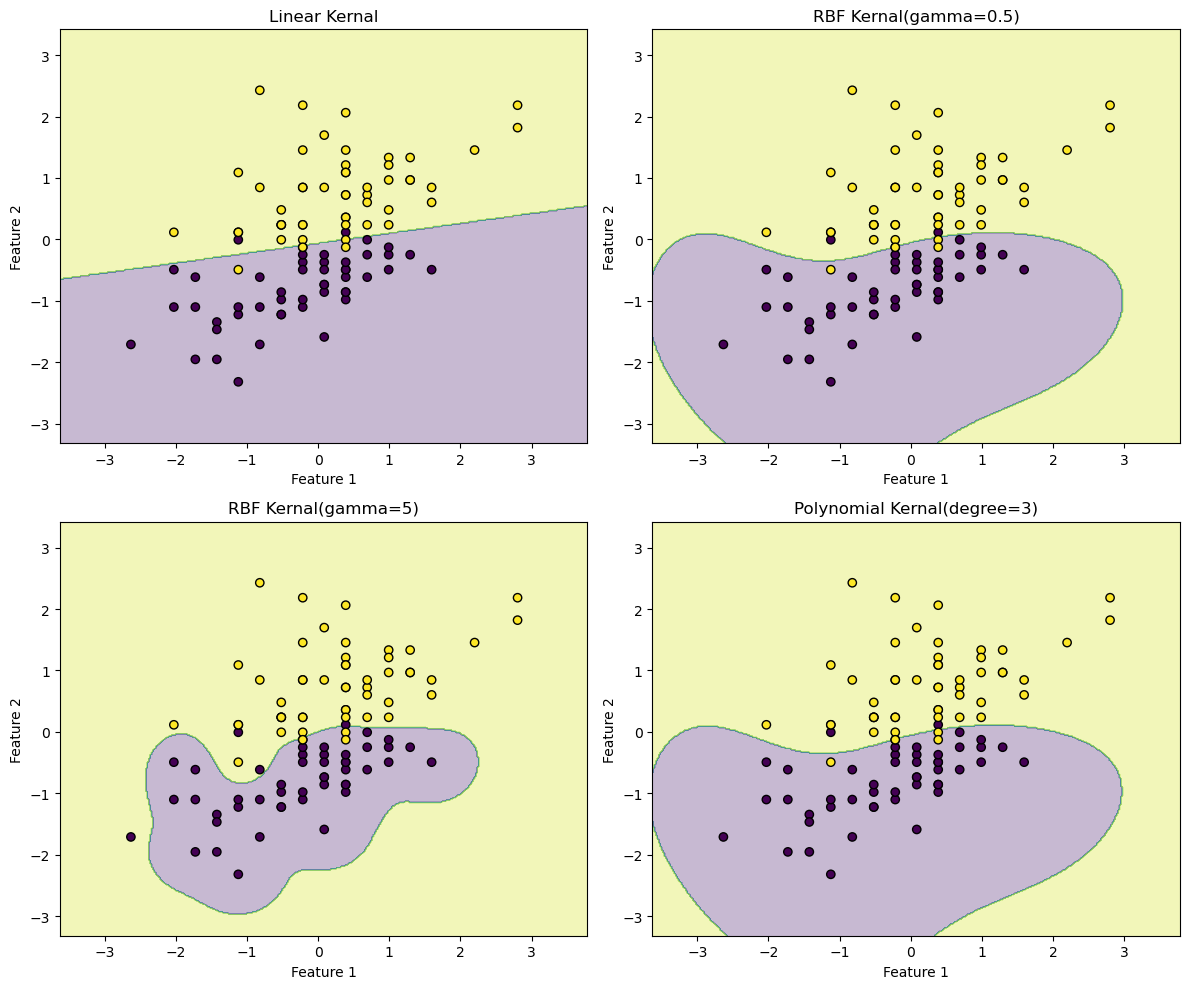

In [76]:
plt.figure(figsize=(12,10))
for i,(title,model) in enumerate(models,1):
    model.fit(X_train,y_train)
    Z=model.predict(np.c_[xx.ravel(),yy.ravel()])
    Z=Z.reshape(xx.shape)
    plt.subplot(2,2,i)
    plt.contourf(xx,yy,Z,alpha=0.3)
    plt.scatter(X[:,0],X[:,1],c=y,edgecolors='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

In [77]:
print("Model Performance")
for title,model in models:
    model.fit(X_train,y_train)
    acc=model.score(X_test,y_test)
    print(f"{title}:{acc:.2f}")

Model Performance
Linear Kernal:0.83
RBF Kernal(gamma=0.5):0.83
RBF Kernal(gamma=5):0.77
Polynomial Kernal(degree=3):0.83


In [42]:
len(model.support_vectors_)

76